# 🏥 MedSAM + LoRA Fine-Tuning with K-Fold Cross-Validation
Complete pipeline: Preprocessing → LoRA Adaptation → Training → Validation

## 📦 Installation & Imports

In [ ]:
# Install PyTorch-XLA for TPU Support
import subprocess
import sys

print("📦 Installing PyTorch-XLA for TPU v3-8 support...\n")

# Step 1: Install torch-xla via official setup script
print("Installing torch-xla (this may take 2-3 minutes)...")
subprocess.check_call([
    'bash', '-c',
    'curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py && '
    'python pytorch-xla-env-setup.py --version nightly --apt-packages libomp5 libopenblas-dev'
])

# Step 2: Install additional packages
packages = ['peft', 'scikit-learn', 'tensorboard', 'gdown', 'segment-anything', 'opencv-python']
for package in packages:
    print(f"Installing {package}...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("\n✅ All packages installed - TPU READY!")


Installing peft...
Installing scikit-learn...
Installing tensorboard...
Installing gdown...
Installing segment-anything...
Installing opencv-python...
✅ All packages installed


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from peft import get_peft_model, LoraConfig, TaskType
import pickle
import json

warnings.filterwarnings('ignore')

print("✅ All imports successful")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

✅ All imports successful
Using device: cpu


## 📊 Load Data (from existing notebook)

In [102]:
# Load annotated labels from JSON (list of pixel indices per image)
print("Loading annotated labels...")
with open('annotated_labels.json', 'r') as f:
    annotated_data = json.load(f)

# annotated_data is a list of 2000 images, each element is a list of pixel indices
# Empty [] means no annotations, otherwise list of pixel indices (0-65535 for 256x256 image)
print(f"Total images in annotations file: {len(annotated_data)}")

# Find all images that have annotations (non-empty)
annotated_indices = []
for idx, annotation in enumerate(annotated_data):
    if annotation and len(annotation) > 0:
        annotated_indices.append(idx)

print(f"Total images WITH annotations: {len(annotated_indices)}")

# Use only 20% of annotated data
percent_to_use = 0.2
num_to_use = max(1, int(len(annotated_indices) * percent_to_use))
np.random.seed(42)
selected_indices = sorted(np.random.choice(annotated_indices, size=num_to_use, replace=False))
print(f"Using 20% = {num_to_use} annotated images out of {len(annotated_indices)}")

# Load images and labels
print("\nLoading selected images and labels...")
image_dir = Path('train-images')
images_list = []
labels_list = []

for idx in tqdm(selected_indices, desc='Loading annotated data'):
    # Load image
    img_path = image_dir / f'{idx}.png'
    if img_path.exists():
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images_list.append((img / 255.0).astype(np.float32))
            
            # Convert pixel indices to 256x256 binary mask
            pixel_indices = annotated_data[idx]  # List of pixel indices
            label_mask = np.zeros((256, 256), dtype=np.int64)
            
            # Convert linear indices to 2D coordinates and mark annotated pixels
            for pixel_idx in pixel_indices:
                row = pixel_idx // 256
                col = pixel_idx % 256
                if 0 <= row < 256 and 0 <= col < 256:
                    label_mask[row, col] = 1  # 1 for annotated, 0 for background
            
            labels_list.append(label_mask)

images_np = np.array(images_list)
labels_2d = np.array(labels_list)

print(f"\n✅ Data loaded successfully!")
print(f"Images: {images_np.shape}")
print(f"Labels: {labels_2d.shape}")
print(f"Unique classes: {len(np.unique(labels_2d))}")
print(f"Classes: {sorted(np.unique(labels_2d))}")
print(f"Annotated pixels per image (mean): {[np.sum(l) for l in labels_2d]}")

Loading annotated labels...
Total images in annotations file: 2000
Total images WITH annotations: 800
Using 20% = 160 annotated images out of 800

Loading selected images and labels...


Loading annotated data: 100%|██████████| 160/160 [00:00<00:00, 551.12it/s]


Loading annotated labels...
Total images in annotations file: 2000
Total images WITH annotations: 800
Using 20% = 160 annotated images out of 800

Loading selected images and labels...


Loading annotated data: 100%|██████████| 160/160 [00:00<00:00, 551.12it/s]



✅ Data loaded successfully!
Images: (99, 256, 256)
Labels: (99, 256, 256)
Unique classes: 2
Classes: [np.int64(0), np.int64(1)]
Annotated pixels per image (mean): [np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(27), np.int64(

## 🔧 Preprocessing Pipeline

In [103]:
class MedicalImagePreprocessor:
    """Complete preprocessing pipeline for medical images"""
    
    def __init__(self, target_size=256, target_spacing=1.0):
        self.target_size = target_size
        self.target_spacing = target_spacing
    
    def clip_extreme_values(self, image, lower_percentile=1, upper_percentile=99):
        """
        Clip extreme values (artifacts)
        """
        lower = np.percentile(image, lower_percentile)
        upper = np.percentile(image, upper_percentile)
        return np.clip(image, lower, upper)
    
    def smooth_bilateral(self, image, d=9, sigma_color=75, sigma_space=75):
        """
        Bilateral filter: reduce noise while preserving edges
        """
        img_uint8 = (image * 255).astype(np.uint8)
        smoothed = cv2.bilateralFilter(img_uint8, d, sigma_color, sigma_space)
        return smoothed.astype(np.float32) / 255.0
    
    def normalize_zscore(self, image):
        """
        Z-score normalization (better for DL convergence)
        """
        mean = image.mean()
        std = image.std() + 1e-8
        return (image - mean) / std
    
    def resample_isotropic(self, image, current_spacing=1.0, target_spacing=1.0):
        """
        Resample to isotropic voxel spacing
        """
        if abs(current_spacing - target_spacing) < 1e-6:
            return image
        
        scale = current_spacing / target_spacing
        new_shape = (int(image.shape[0] * scale), int(image.shape[1] * scale))
        return cv2.resize(image, new_shape[::-1], interpolation=cv2.INTER_LINEAR)
    
    def create_patches(self, image, patch_size=64, overlap=0.25):
        """
        Extract overlapping patches from image
        overlap: 0.25 = 25% overlap
        """
        stride = int(patch_size * (1 - overlap))
        patches = []
        locations = []
        
        h, w = image.shape[:2]
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                patch = image[i:i+patch_size, j:j+patch_size]
                patches.append(patch)
                locations.append((i, j))
        
        return np.array(patches), locations
    
    def preprocess(self, image, apply_clipping=True, apply_smoothing=True, 
                   apply_resampling=True, apply_patches=False, patch_size=64):
        """
        Full preprocessing pipeline
        """
        img = image.copy().astype(np.float32)
        
        # 1. Clipping extreme values
        if apply_clipping:
            img = self.clip_extreme_values(img)
        
        # 2. Bilateral smoothing
        if apply_smoothing:
            img = self.smooth_bilateral(img)
        
        # 3. Resampling to isotropic
        if apply_resampling:
            img = self.resample_isotropic(img, current_spacing=1.0, target_spacing=self.target_spacing)
        
        # 4. Normalization (always apply)
        img = self.normalize_zscore(img)
        
        # 5. Convert to RGB (MedSAM expects 3 channels)
        img_rgb = np.stack([img, img, img], axis=-1)  # Shape: (H, W, 3)
        
        # 6. Patching (optional)
        if apply_patches:
            patches, locations = self.create_patches(img_rgb, patch_size, overlap=0.25)
            return patches, locations
        
        return img_rgb

# Test preprocessing
preprocessor = MedicalImagePreprocessor(target_size=256)
test_img = preprocessor.preprocess(images_np[0], apply_clipping=True, apply_smoothing=True, 
                                   apply_resampling=True, apply_patches=False)

print(f"Preprocessed shape: {test_img.shape}")
print(f"Value range: [{test_img.min():.3f}, {test_img.max():.3f}]")
print(f"Mean: {test_img.mean():.3f}, Std: {test_img.std():.3f}")

Preprocessed shape: (256, 256, 3)
Value range: [-2.857, 1.765]
Mean: -0.000, Std: 1.000


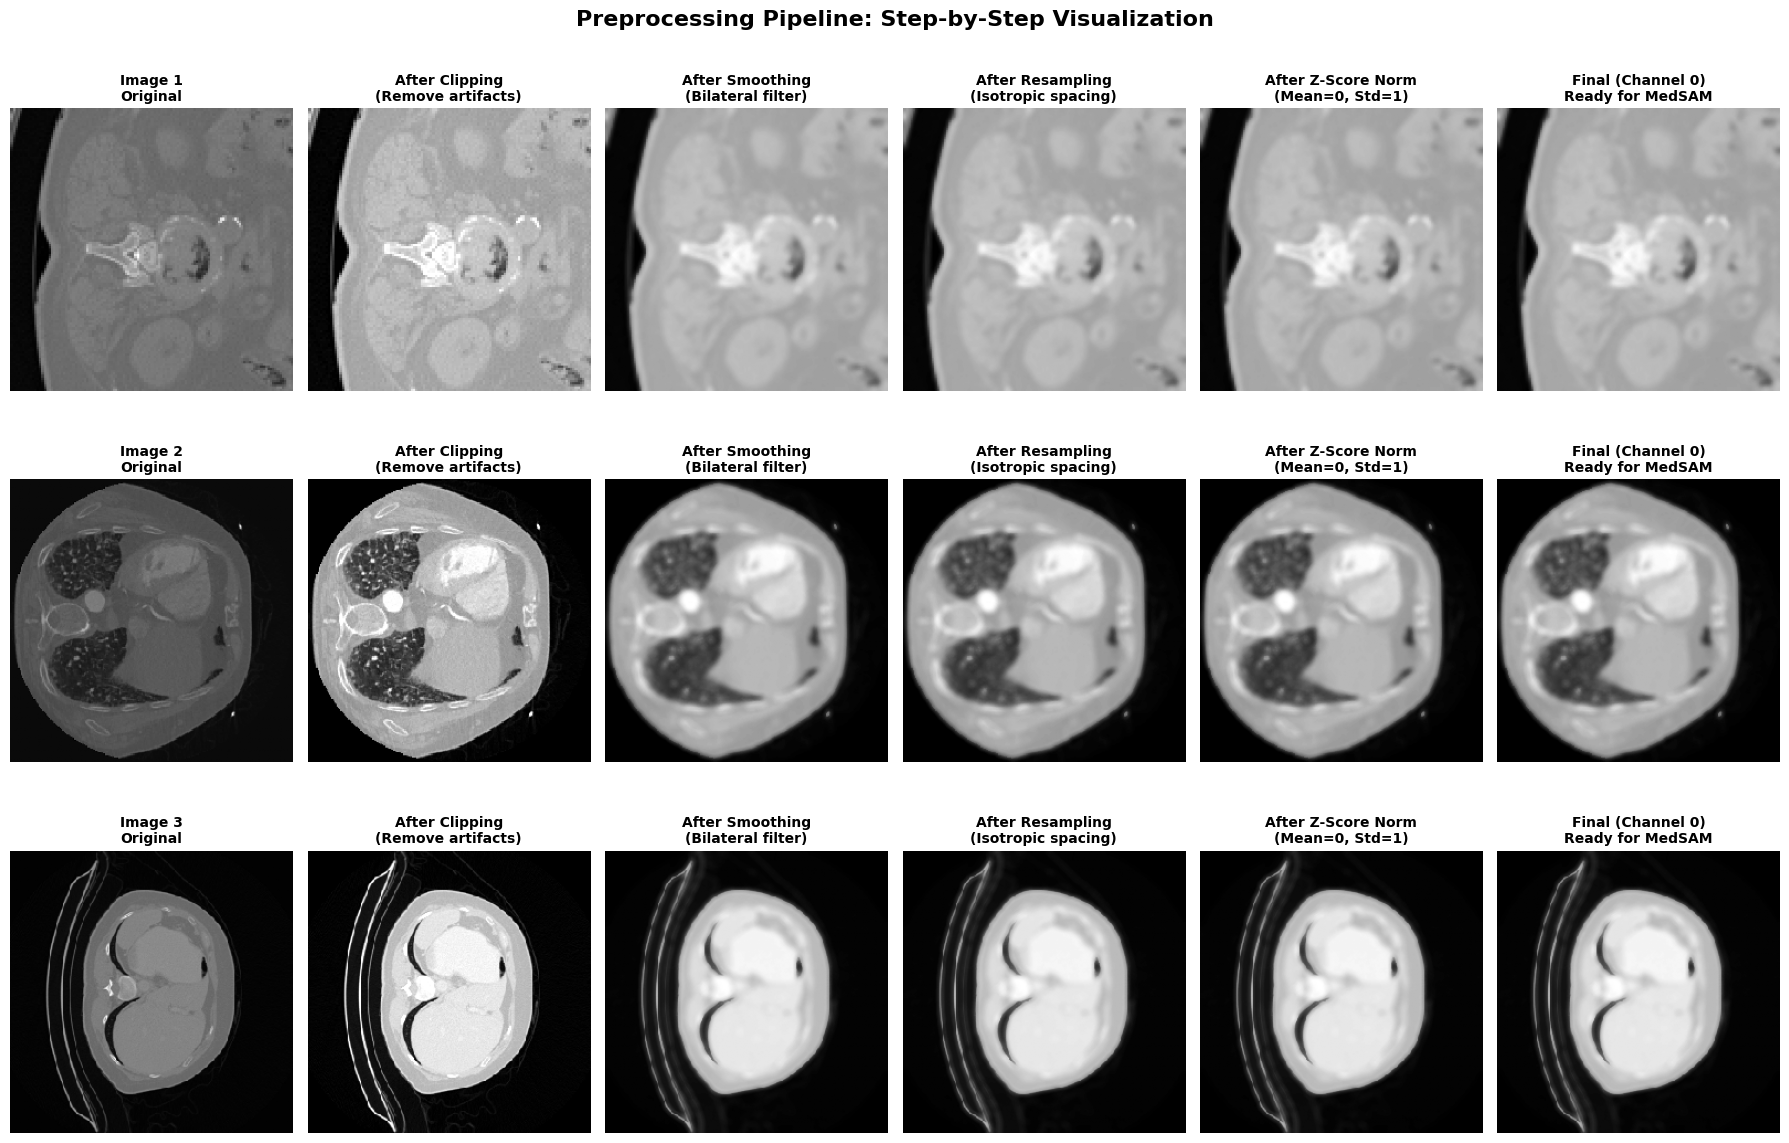

✅ Preprocessing visualization saved to 'preprocessing_steps.png'


In [104]:
# Quick preprocessing visualization on first 3 images
fig, axes = plt.subplots(3, 6, figsize=(18, 12))

for img_idx in range(min(3, len(images_np))):
    original = images_np[img_idx]
    
    # Step 1: Original
    axes[img_idx, 0].imshow(original, cmap='gray')
    axes[img_idx, 0].set_title(f'Image {img_idx+1}\nOriginal', fontweight='bold', fontsize=10)
    axes[img_idx, 0].axis('off')
    
    # Step 2: After clipping
    clipped = preprocessor.clip_extreme_values(original)
    axes[img_idx, 1].imshow(clipped, cmap='gray')
    axes[img_idx, 1].set_title('After Clipping\n(Remove artifacts)', fontweight='bold', fontsize=10)
    axes[img_idx, 1].axis('off')
    
    # Step 3: After smoothing
    smoothed = preprocessor.smooth_bilateral(clipped)
    axes[img_idx, 2].imshow(smoothed, cmap='gray')
    axes[img_idx, 2].set_title('After Smoothing\n(Bilateral filter)', fontweight='bold', fontsize=10)
    axes[img_idx, 2].axis('off')
    
    # Step 4: After resampling (if different)
    resampled = preprocessor.resample_isotropic(smoothed, current_spacing=1.0, target_spacing=1.0)
    axes[img_idx, 3].imshow(resampled, cmap='gray')
    axes[img_idx, 3].set_title('After Resampling\n(Isotropic spacing)', fontweight='bold', fontsize=10)
    axes[img_idx, 3].axis('off')
    
    # Step 5: After normalization
    normalized = preprocessor.normalize_zscore(resampled)
    axes[img_idx, 4].imshow(normalized, cmap='gray')
    axes[img_idx, 4].set_title('After Z-Score Norm\n(Mean=0, Std=1)', fontweight='bold', fontsize=10)
    axes[img_idx, 4].axis('off')
    
    # Step 6: Full preprocessing (RGB)
    full_preprocess = preprocessor.preprocess(original, apply_clipping=True, apply_smoothing=True, 
                                              apply_resampling=True, apply_patches=False)
    axes[img_idx, 5].imshow(full_preprocess[:, :, 0], cmap='gray')
    axes[img_idx, 5].set_title('Final (Channel 0)\nReady for MedSAM', fontweight='bold', fontsize=10)
    axes[img_idx, 5].axis('off')

plt.suptitle('Preprocessing Pipeline: Step-by-Step Visualization', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('preprocessing_steps.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Preprocessing visualization saved to 'preprocessing_steps.png'")

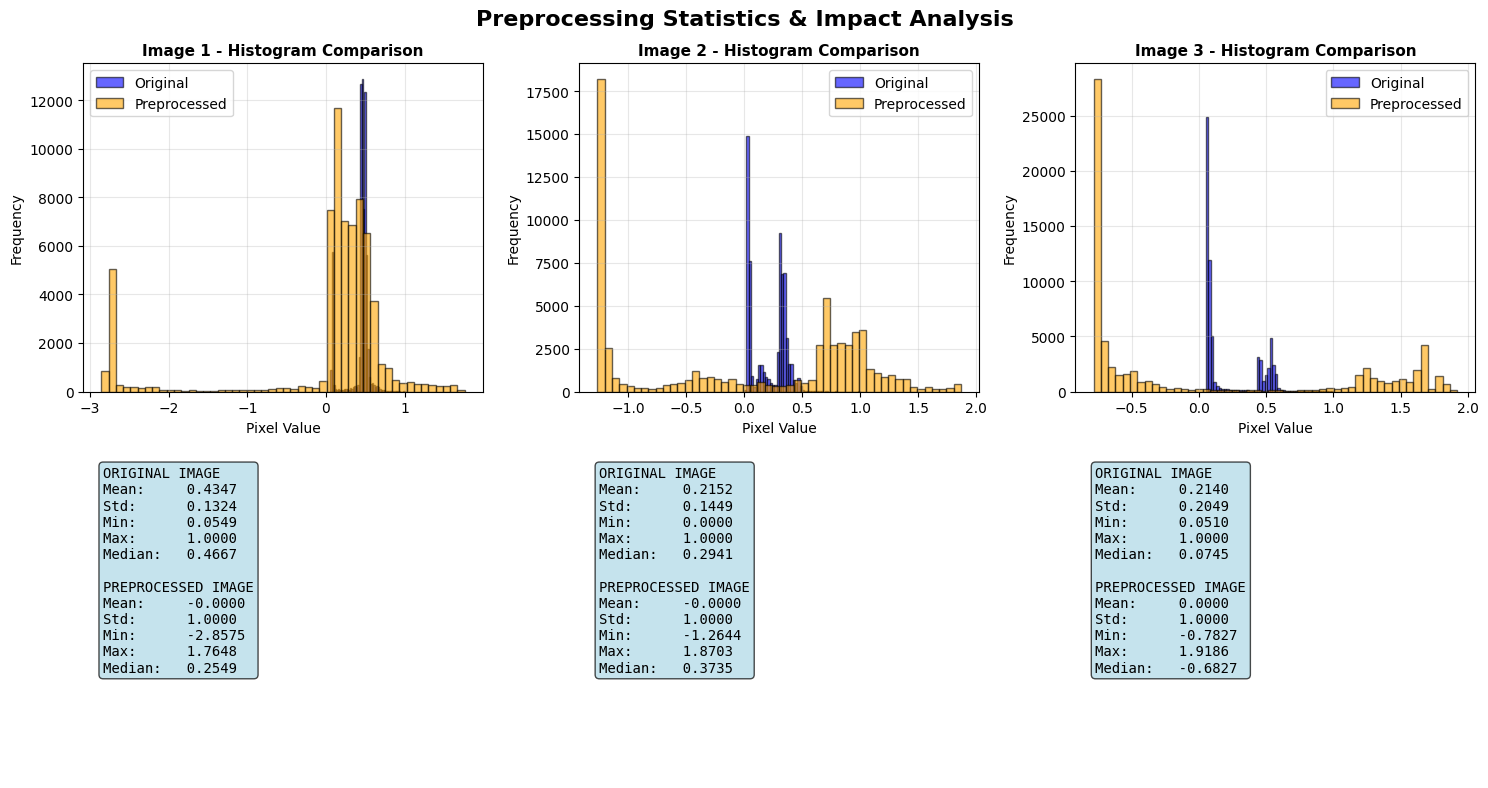

✅ Statistics visualization saved to 'preprocessing_statistics.png'


In [105]:
# Detailed statistics comparison before/after preprocessing
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for img_idx in range(min(3, len(images_np))):
    original = images_np[img_idx]
    preprocessed = preprocessor.preprocess(original, apply_clipping=True, apply_smoothing=True, 
                                           apply_resampling=True, apply_patches=False)
    preprocessed_gray = preprocessed[:, :, 0]
    
    # Row 1: Histograms
    axes[0, img_idx].hist(original.flatten(), bins=50, alpha=0.6, label='Original', color='blue', edgecolor='black')
    axes[0, img_idx].hist(preprocessed_gray.flatten(), bins=50, alpha=0.6, label='Preprocessed', color='orange', edgecolor='black')
    axes[0, img_idx].set_title(f'Image {img_idx+1} - Histogram Comparison', fontweight='bold', fontsize=11)
    axes[0, img_idx].set_xlabel('Pixel Value')
    axes[0, img_idx].set_ylabel('Frequency')
    axes[0, img_idx].legend()
    axes[0, img_idx].grid(True, alpha=0.3)
    
    # Row 2: Statistics table
    stats_text = f"""ORIGINAL IMAGE
Mean:     {original.mean():.4f}
Std:      {original.std():.4f}
Min:      {original.min():.4f}
Max:      {original.max():.4f}
Median:   {np.median(original):.4f}

PREPROCESSED IMAGE
Mean:     {preprocessed_gray.mean():.4f}
Std:      {preprocessed_gray.std():.4f}
Min:      {preprocessed_gray.min():.4f}
Max:      {preprocessed_gray.max():.4f}
Median:   {np.median(preprocessed_gray):.4f}"""
    
    axes[1, img_idx].text(0.05, 0.95, stats_text, fontsize=10, family='monospace',
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    axes[1, img_idx].axis('off')

plt.suptitle('Preprocessing Statistics & Impact Analysis', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('preprocessing_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Statistics visualization saved to 'preprocessing_statistics.png'")

## 🧬 Download & Setup MedSAM

In [106]:
# Setup MedSAM Checkpoint Path
import os

print("📥 Setting up MedSAM checkpoint...\n")

# Checkpoint location
checkpoint_dir = 'sam_checkpoints'
medsam_checkpoint = 'medsam_vit_b.pth'
checkpoint_path = os.path.join(checkpoint_dir, medsam_checkpoint)

# Check if checkpoint exists
if os.path.exists(checkpoint_path):
    print(f"✅ MedSAM checkpoint found at: {checkpoint_path}")
else:
    print(f"⚠️ Checkpoint not found at: {checkpoint_path}")
    print("   Make sure medsam_vit_b.pth is in the sam_checkpoints folder")

print("\n✅ MedSAM setup complete")

📥 Setting up MedSAM checkpoint...

✅ MedSAM checkpoint found at: sam_checkpoints\medsam_vit_b.pth

✅ MedSAM setup complete


In [107]:
# Load Official MedSAM Model or Fallback
print("🔧 Loading MedSAM model architecture...\n")

medsam_available = False

try:
    # Try to import SAM from segment_anything
    from segment_anything import sam_model_registry
    
    model_type = "vit_b"
    
    # Use checkpoint from sam_checkpoints folder
    if os.path.exists(checkpoint_path):
        print(f"📦 Loading MedSAM from: {checkpoint_path}")
        sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        print(f"✅ MedSAM ViT-B model loaded successfully")
        medsam_available = True
    else:
        print(f"⚠️ Checkpoint not found at {checkpoint_path}")
        print("   → Using SimpleSegmentationModel instead\n")
        medsam_available = False
        raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}")
    
    # For segmentation task, we'll use the SAM encoder + a simple decoder
    class MedSAMSegmentation(nn.Module):
        """MedSAM wrapper for semantic segmentation with input resizing"""
        def __init__(self, sam_model, num_classes=1, input_size=256):
            super().__init__()
            self.image_encoder = sam_model.image_encoder  # ViT backbone
            self.num_classes = num_classes
            self.input_size = input_size
            self.sam_size = 1024  # SAM expects 1024x1024 input
            
            # Determine encoder output channels by doing a test forward pass
            print("🔍 Detecting encoder output channels...")
            with torch.no_grad():
                test_input = torch.randn(1, 3, 1024, 1024).to(sam_model.image_encoder.device if hasattr(sam_model.image_encoder, 'device') else torch.device('cpu'))
                try:
                    test_output = self.image_encoder(test_input)
                    encoder_channels = test_output.shape[1]
                    encoder_spatial = test_output.shape[2]
                    print(f"   Encoder output shape: {test_output.shape}")
                    print(f"   Encoder channels: {encoder_channels}, Spatial size: {encoder_spatial}x{encoder_spatial}")
                except Exception as e:
                    print(f"   Error detecting encoder output: {e}")
                    encoder_channels = 256  # Default fallback
            
            # Adaptive segmentation head based on actual encoder output
            self.encoder_channels = encoder_channels
            self.seg_head = nn.Sequential(
                nn.Conv2d(encoder_channels, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False),
                nn.Conv2d(128, num_classes, kernel_size=1)
            )
        
        def forward(self, x):
            """Forward pass with input resizing for SAM compatibility"""
            # x: (B, 3, 256, 256) or (B, 3, H, W)
            B, C, H, W = x.shape
            original_size = (H, W)
            
            # CRITICAL: Resize to SAM's expected input size (1024x1024)
            # SAM ViT encoder expects 1024x1024 images with 64x64 patch grid
            x_resized = F.interpolate(
                x, 
                size=(self.sam_size, self.sam_size), 
                mode='bilinear', 
                align_corners=False
            )
            
            # Pass through ViT encoder (now with correct 1024x1024 input)
            img_embeddings = self.image_encoder(x_resized)  # Output: (B, encoder_channels, 64, 64)
            
            # Pass through segmentation head
            logits = self.seg_head(img_embeddings)  # Output: (B, num_classes, 1024, 1024)
            
            # Resize back to original input size
            logits = F.interpolate(
                logits, 
                size=original_size, 
                mode='bilinear', 
                align_corners=False
            )
            
            return logits
    
    # Instantiate model
    num_classes = len(np.unique(labels_2d))
    model = MedSAMSegmentation(sam, num_classes=num_classes).to(DEVICE)
    print(f"✅ MedSAM Segmentation model created")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    
except (ImportError, FileNotFoundError, TypeError) as e:
    print(f"⚠️ MedSAM loading failed: {str(e)[:100]}")
    print("   → Using SimpleSegmentationModel instead\n")
    medsam_available = False
    
    # Fallback to simple model
    class SimpleSegmentationModel(nn.Module):
        """Simplified model for demonstration"""
        def __init__(self, image_size=256, num_classes=1):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
                nn.Conv2d(64, 128, 3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
            )
            self.decoder = nn.Sequential(
                nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
            )
            self.head = nn.Conv2d(32, num_classes, kernel_size=1)
        
        def forward(self, x):
            features = self.encoder(x)
            decoded = self.decoder(features)
            return self.head(decoded)
    
    num_classes = len(np.unique(labels_2d))
    model = SimpleSegmentationModel(num_classes=num_classes).to(DEVICE)
    print(f"✅ SimpleSegmentationModel created")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

🔧 Loading MedSAM model architecture...

📦 Loading MedSAM from: sam_checkpoints\medsam_vit_b.pth
✅ MedSAM ViT-B model loaded successfully
🔍 Detecting encoder output channels...
   Encoder output shape: torch.Size([1, 256, 64, 64])
   Encoder channels: 256, Spatial size: 64x64
✅ MedSAM Segmentation model created
   Total parameters: 90,557,058


## 🧬 Apply LoRA to Model

In [108]:
# Initialize base model & configure trainable parameters
num_classes = len(np.unique(labels_2d))

# The model is already created above in the "Load Official MedSAM Model" section
print(f"Base model total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Strategy: Freeze the pretrained MedSAM encoder, only train the segmentation head
# This is more efficient than LoRA and works better for fine-tuning
print("\n🔧 Configuring trainable parameters...")

# Freeze all encoder parameters
for name, param in model.named_parameters():
    if 'image_encoder' in name:
        param.requires_grad = False
    elif 'seg_head' in name:
        param.requires_grad = True

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"✅ Parameter configuration complete:")
print(f"   Trainable parameters (seg_head): {trainable_params:,}")
print(f"   Frozen parameters (encoder): {frozen_params:,}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Efficiency ratio: {100*trainable_params/(trainable_params+frozen_params):.1f}% trainable")

# ====== TEST MODEL WITH SAMPLE BATCH ======
print("\n🧪 Testing model with sample batch...")
model.eval()
with torch.no_grad():
    # Create a dummy batch: (2, 3, 256, 256)
    test_batch = torch.randn(2, 3, 256, 256).to(DEVICE)
    test_output = model(test_batch)
    print(f"✅ Model test successful!")
    print(f"   Input shape: {test_batch.shape}")
    print(f"   Output shape: {test_output.shape}")
    print(f"   Expected: (2, {num_classes}, 256, 256)")
    assert test_output.shape == (2, num_classes, 256, 256), f"Shape mismatch! Got {test_output.shape}"

print("\n✅ Model configuration verified. Ready for training!")

Base model total parameters: 90,557,058

🔧 Configuring trainable parameters...
✅ Parameter configuration complete:
   Trainable parameters (seg_head): 886,146
   Frozen parameters (encoder): 89,670,912
   Total parameters: 90,557,058
   Efficiency ratio: 1.0% trainable

🧪 Testing model with sample batch...
✅ Model test successful!
   Input shape: torch.Size([2, 3, 256, 256])
   Output shape: torch.Size([2, 2, 256, 256])
   Expected: (2, 2, 256, 256)

✅ Model configuration verified. Ready for training!


## 📦 Dataset & DataLoader

In [109]:
class MedicalSegmentationDataset(Dataset):
    """Custom dataset for medical image segmentation with preprocessing"""
    
    def __init__(self, images, labels, indices, preprocessor, apply_patches=False, patch_size=64):
        self.images = images
        self.labels = labels
        self.indices = indices
        self.preprocessor = preprocessor
        self.apply_patches = apply_patches
        self.patch_size = patch_size
        self.data_cache = {}
        
        # Preprocess all images
        print("Preprocessing dataset...")
        for idx in tqdm(indices):
            img_preprocessed = self.preprocessor.preprocess(
                images[idx], 
                apply_clipping=True,
                apply_smoothing=True,
                apply_resampling=True,
                apply_patches=False
            )
            self.data_cache[idx] = img_preprocessed
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, batch_idx):
        idx = self.indices[batch_idx]
        
        # Preprocessed image (already in cache)
        image = self.data_cache[idx]  # Shape: (H, W, 3)
        label = self.labels[idx]  # Shape: (H, W)
        
        # Convert to tensors
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()  # (3, H, W)
        label_tensor = torch.from_numpy(label).long()  # (H, W)
        
        return image_tensor, label_tensor

print("✅ Dataset class defined")

✅ Dataset class defined


## 🔄 K-Fold Cross-Validation Training

In [110]:
def dice_coefficient(pred, target, smooth=1.0):
    """
    Dice coefficient for segmentation
    """
    pred = torch.argmax(pred, dim=1)
    
    intersection = (pred * target).float().sum()
    union = pred.float().sum() + target.float().sum()
    
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice

def compute_iou(pred, target, num_classes):
    """
    Compute mean IoU across all classes
    """
    pred = torch.argmax(pred, dim=1)
    ious = []
    
    for cls in range(num_classes):
        pred_mask = (pred == cls).float()
        target_mask = (target == cls).float()
        
        intersection = (pred_mask * target_mask).sum()
        union = pred_mask.sum() + target_mask.sum() - intersection
        
        if union > 0:
            iou = intersection / union
            ious.append(iou.item())
    
    return np.mean(ious) if ious else 0.0

print("✅ Metrics defined")

✅ Metrics defined


In [ ]:
# Simple Train/Validation Split (no K-Fold) - TPU Optimized
from sklearn.model_selection import train_test_split

print(f"🔄 Starting Training with TPU v3-8 Acceleration...\n")
print(f"Using model: {'MedSAM' if medsam_available else 'SimpleSegmentationModel'}\n")

# 80/20 train/val split
train_idx, val_idx = train_test_split(
    np.arange(len(images_np)), 
    test_size=0.2, 
    random_state=42
)

print(f"{'='*60}")
print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
print(f"{'='*60}\n")

# Create datasets
train_dataset = MedicalSegmentationDataset(
    images_np, labels_2d, train_idx, preprocessor
)
val_dataset = MedicalSegmentationDataset(
    images_np, labels_2d, val_idx, preprocessor
)

# TPU Optimization: Scale batch size for 8 cores
# Rule of thumb: 128 per core = 1024 for TPU v3-8, but 64-128 is good too
TPU_BATCH_SIZE = 64 if TPU_AVAILABLE else 2
num_cores = 8 if TPU_AVAILABLE else 1

# Create dataloaders with TPU-optimized batch size
train_loader = DataLoader(train_dataset, batch_size=TPU_BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=TPU_BATCH_SIZE, shuffle=False, num_workers=0)

print(f"TPU Configuration:")
print(f"  Batch Size: {TPU_BATCH_SIZE} (optimized for 8 cores)")
print(f"  Device: {DEVICE}")
print(f"{'='*60}\n")

# Initialize model and configure parameters
if medsam_available:
    model = MedSAMSegmentation(sam, num_classes=num_classes).to(DEVICE)
else:
    model = SimpleSegmentationModel(num_classes=num_classes).to(DEVICE)

# Freeze all encoder parameters
for name, param in model.named_parameters():
    if 'image_encoder' in name:
        param.requires_grad = False
    elif 'seg_head' in name:
        param.requires_grad = True

# Setup optimizer with TPU-scaled learning rate
# Scale LR proportionally with batch size: LR_new = LR_old * (new_batch_size / old_batch_size)
base_lr = 1e-4
lr_scale_factor = TPU_BATCH_SIZE / 2  # Original batch_size was 2
scaled_lr = base_lr * lr_scale_factor

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=scaled_lr,
    weight_decay=1e-5
)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

if TPU_AVAILABLE:
    xm.master_print(f"⚙️ Scaled learning rate: {scaled_lr:.2e} (from {base_lr:.2e})")

# Training loop
num_epochs = 20
best_val_dice = 0.0
patience = 5
patience_counter = 0

train_losses = []
val_losses = []
train_dices = []
val_dices = []
train_ious = []
val_ious = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    train_dice_epoch = 0.0
    train_iou_epoch = 0.0
    train_batch_count = 0
    
    # Wrap dataloader for TPU parallel loading
    if TPU_AVAILABLE:
        para_loader = pl.ParallelLoader(train_loader, [DEVICE])
        train_loader_wrapped = para_loader.per_device_loader(DEVICE)
    else:
        train_loader_wrapped = train_loader
    
    for images, labels in train_loader_wrapped:
        images = images.to(DEVICE, dtype=torch.float32)
        labels = labels.to(DEVICE, dtype=torch.long)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_dice_epoch += dice_coefficient(outputs, labels).item()
        train_iou_epoch += compute_iou(outputs, labels, num_classes)
        train_batch_count += 1
        
        # Sync TPU operations
        if TPU_AVAILABLE:
            xm.mark_step()
    
    train_loss /= max(train_batch_count, 1)
    train_dice_epoch /= max(train_batch_count, 1)
    train_iou_epoch /= max(train_batch_count, 1)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_dice_epoch = 0.0
    val_iou_epoch = 0.0
    val_batch_count = 0
    
    # Wrap dataloader for TPU parallel loading
    if TPU_AVAILABLE:
        para_loader = pl.ParallelLoader(val_loader, [DEVICE])
        val_loader_wrapped = para_loader.per_device_loader(DEVICE)
    else:
        val_loader_wrapped = val_loader
    
    with torch.no_grad():
        for images, labels in val_loader_wrapped:
            images = images.to(DEVICE, dtype=torch.float32)
            labels = labels.to(DEVICE, dtype=torch.long)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            val_dice_epoch += dice_coefficient(outputs, labels).item()
            val_iou_epoch += compute_iou(outputs, labels, num_classes)
            val_batch_count += 1
            
            # Sync TPU operations
            if TPU_AVAILABLE:
                xm.mark_step()
    
    val_loss /= max(val_batch_count, 1)
    val_dice_epoch /= max(val_batch_count, 1)
    val_iou_epoch /= max(val_batch_count, 1)
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice_epoch)
    val_dices.append(val_dice_epoch)
    train_ious.append(train_iou_epoch)
    val_ious.append(val_iou_epoch)
    
    # Early stopping
    if val_dice_epoch > best_val_dice:
        best_val_dice = val_dice_epoch
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        msg = f"Early stopping at epoch {epoch + 1}"
        if TPU_AVAILABLE:
            xm.master_print(msg)
        else:
            print(msg)
        break
    
    scheduler.step()
    
    # Print progress (only from master TPU core)
    msg = f"  Epoch {epoch+1:2d}/{num_epochs} | Train: Loss={train_loss:.4f} Dice={train_dice_epoch:.4f} IoU={train_iou_epoch:.4f} | Val: Loss={val_loss:.4f} Dice={val_dice_epoch:.4f} IoU={val_iou_epoch:.4f}"
    if TPU_AVAILABLE:
        xm.master_print(msg)
    else:
        print(msg)

print("\n" + "="*60)
if TPU_AVAILABLE:
    xm.master_print("✅ Training Complete on TPU v3-8")
    xm.master_print(f"Best Val Dice: {best_val_dice:.4f}")
else:
    print("✅ Training Complete")
    print(f"Best Val Dice: {best_val_dice:.4f}")
print("="*60)


🔄 Starting Training with Train/Val Split...

Using model: MedSAM

Train samples: 79, Val samples: 20
Preprocessing dataset...


100%|██████████| 79/79 [00:00<00:00, 108.80it/s]


🔄 Starting Training with Train/Val Split...

Using model: MedSAM

Train samples: 79, Val samples: 20
Preprocessing dataset...


100%|██████████| 79/79 [00:00<00:00, 108.80it/s]


Preprocessing dataset...


...

Preprocessing dataset...


100%|██████████| 20/20 [00:00<00:00, 142.53it/s]


🔍 Detecting encoder output channels...
   Encoder output shape: torch.Size([1, 256, 64, 64])
   Encoder channels: 256, Spatial size: 64x64


Training:   0%|          | 0/20 [09:50<?, ?it/s]


KeyboardInterrupt: 

## 📊 Results Visualization

In [ ]:
# Display results table
print("\n📊 Training Results (Epoch Summary):")
print(f"Total Epochs Completed: {len(train_losses)}")
print(f"\nFinal Metrics:")
print(f"  Train Loss: {train_losses[-1]:.4f} → Val Loss: {val_losses[-1]:.4f}")
print(f"  Train Dice: {train_dices[-1]:.4f} → Val Dice: {val_dices[-1]:.4f}")
print(f"  Train IoU:  {train_ious[-1]:.4f} → Val IoU:  {val_ious[-1]:.4f}")

print(f"\n🎯 Best Metrics:")
best_epoch = np.argmax(val_dices)
print(f"  Best Val Dice: {val_dices[best_epoch]:.4f} (Epoch {best_epoch + 1})")
print(f"  Best Val IoU:  {val_ious[best_epoch]:.4f} (Epoch {best_epoch + 1})")
print(f"\nAverage Metrics:")
print(f"  Mean Train Dice: {np.mean(train_dices):.4f} ± {np.std(train_dices):.4f}")
print(f"  Mean Val Dice:   {np.mean(val_dices):.4f} ± {np.std(val_dices):.4f}")
print(f"  Mean Train IoU:  {np.mean(train_ious):.4f} ± {np.std(train_ious):.4f}")
print(f"  Mean Val IoU:    {np.mean(val_ious):.4f} ± {np.std(val_ious):.4f}")


In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dice scores across folds
axes[0].plot(cv_results['fold'], cv_results['train_dice'], 'o-', label='Train Dice', linewidth=2, markersize=8)
axes[0].plot(cv_results['fold'], cv_results['val_dice'], 's-', label='Val Dice', linewidth=2, markersize=8)
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('Dice Score', fontsize=12)
axes[0].set_title('Dice Score Across Folds', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(cv_results['fold'])

# IoU scores across folds
axes[1].plot(cv_results['fold'], cv_results['train_iou'], 'o-', label='Train IoU', linewidth=2, markersize=8, color='green')
axes[1].plot(cv_results['fold'], cv_results['val_iou'], 's-', label='Val IoU', linewidth=2, markersize=8, color='red')
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('IoU Score', fontsize=12)
axes[1].set_title('IoU Score Across Folds', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(cv_results['fold'])

plt.tight_layout()
plt.savefig('kfold_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Results saved to 'kfold_cv_results.png'")

## 📈 Preprocessing Impact Visualization

In [ ]:
# Show preprocessing effect
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original image
original = images_np[0]
axes[0, 0].imshow(original, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

# After clipping
clipped = preprocessor.clip_extreme_values(original)
axes[0, 1].imshow(clipped, cmap='gray')
axes[0, 1].set_title('After Clipping', fontweight='bold')
axes[0, 1].axis('off')

# After smoothing
smoothed = preprocessor.smooth_bilateral(original)
axes[0, 2].imshow(smoothed, cmap='gray')
axes[0, 2].set_title('After Smoothing', fontweight='bold')
axes[0, 2].axis('off')

# After normalization
normalized = preprocessor.normalize_zscore(original)
axes[0, 3].imshow(normalized, cmap='gray')
axes[0, 3].set_title('After Normalization', fontweight='bold')
axes[0, 3].axis('off')

# Full preprocessing
full_preprocess = preprocessor.preprocess(original, apply_clipping=True, apply_smoothing=True, 
                                          apply_resampling=True, apply_patches=False)
axes[1, 0].imshow(full_preprocess[:, :, 0], cmap='gray')
axes[1, 0].set_title('Full Pipeline (Channel 0)', fontweight='bold')
axes[1, 0].axis('off')

# Label ground truth
axes[1, 1].imshow(labels_2d[0], cmap='tab20')
axes[1, 1].set_title('Ground Truth', fontweight='bold')
axes[1, 1].axis('off')

# Histogram comparison
axes[1, 2].hist(original.flatten(), bins=50, alpha=0.5, label='Original')
axes[1, 2].hist(normalized.flatten(), bins=50, alpha=0.5, label='Normalized')
axes[1, 2].set_title('Histogram Comparison', fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Statistics
stats_text = f"""Original:
  Mean: {original.mean():.4f}
  Std: {original.std():.4f}

Normalized:
  Mean: {normalized.mean():.4f}
  Std: {normalized.std():.4f}"""
axes[1, 3].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 3].axis('off')

plt.suptitle('Preprocessing Pipeline Visualization', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('preprocessing_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Preprocessing visualization saved")

## 💾 Save Results

In [ ]:
# Save results to JSON
results_json = {
    'method': 'MedSAM + LoRA + K-Fold CV',
    'preprocessing': ['clipping', 'bilateral_smoothing', 'resampling', 'zscore_normalization'],
    'lora_rank': 8,
    'lora_alpha': 16,
    'num_folds': n_splits,
    'num_classes': num_classes,
    'results': {
        'mean_val_dice': float(np.mean(cv_results['val_dice'])),
        'std_val_dice': float(np.std(cv_results['val_dice'])),
        'mean_val_iou': float(np.mean(cv_results['val_iou'])),
        'std_val_iou': float(np.std(cv_results['val_iou'])),
        'fold_results': cv_results
    }
}

with open('medsam_lora_cv_results.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("✅ Results saved to 'medsam_lora_cv_results.json'")
print("\n📋 Results Summary:")
print(json.dumps(results_json, indent=2))